# Assignment 2 — Learning Strategy
**Mata Kuliah:** Pembelajaran Mesin Mendalam (Deep Learning)

**Nama :** Aulia Fathus Tsani

**NIM  :** 24/534388/PA/22661

Notebook ini terdiri dari dua bagian:
1. **Replikasi kode** klasifikasi MNIST dari slide *Learning Strategy* (halaman 14–23)
2. **Eksperimen** penerapan L1 regularization, L2 regularization, Dropout, Early Stopping, dan kombinasi L1+Dropout — masing-masing dilengkapi `model.summary()`, performa, dan grafik loss

## 0. Import Library

In [27]:
import numpy as np
import matplotlib.pyplot as plt

import keras
from keras.models import Sequential
from keras.layers import Flatten, Dense, Dropout, Input
from keras import regularizers
from keras.callbacks import EarlyStopping

## 1. Replikasi Kode (Slide 14–23)
### 1.1 Load Data

In [28]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print('X_train', X_train.shape)
print('X_test', X_test.shape)

X_train (60000, 28, 28, 1)
X_test (10000, 28, 28, 1)


### 1.2 Define Model

In [29]:
model1 = Sequential()
model1.add(Input(shape=(28, 28, 1)))
model1.add(Flatten())
model1.add(Dense(64, activation='relu'))
model1.add(Dense(10, activation='softmax'))

### 1.3 Compile Model, Fit Model, Save Model, and Evaluate Model

In [30]:
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])

history1 = model1.fit(
    X_train, y_train,
    epochs=10, batch_size=100,
    validation_data=(X_test, y_test)
)

model1.save('my_model1.h5')
model1.evaluate(X_test, y_test)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.8927 - loss: 0.3878 - val_acc: 0.9399 - val_loss: 0.2150
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9454 - loss: 0.1934 - val_acc: 0.9527 - val_loss: 0.1629
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9574 - loss: 0.1477 - val_acc: 0.9591 - val_loss: 0.1326
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9656 - loss: 0.1197 - val_acc: 0.9641 - val_loss: 0.1201
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9709 - loss: 0.1009 - val_acc: 0.9679 - val_loss: 0.1045
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9753 - loss: 0.0858 - val_acc: 0.9687 - val_loss: 0.1008
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9782 - loss: 0.0746 - val_acc: 0.9716 - val_loss: 0.0938
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.9810 - loss: 0.0665 - val_acc: 0.9703 - val_loss: 0.0961
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - ac

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9745 - loss: 0.0836


[0.08359919488430023, 0.9745000004768372]

### 1.4 Visualize Model Evaluation

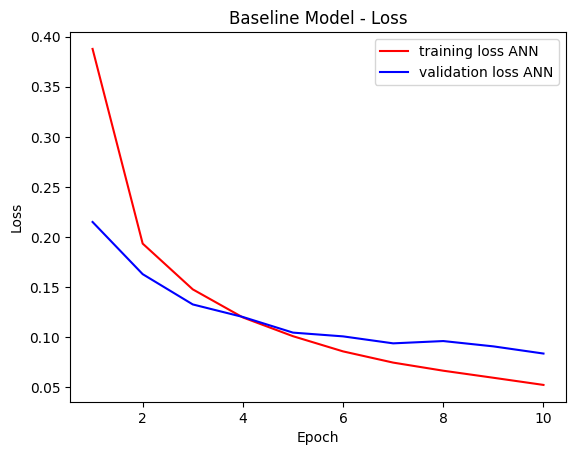

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

In [31]:
epochs = range(1, len(history1.history['loss']) + 1)
loss1 = history1.history['loss']
val_loss1 = history1.history['val_loss']

plt.plot(epochs, loss1, 'r', label='training loss ANN')
plt.plot(epochs, val_loss1, 'b', label='validation loss ANN')
plt.title('Baseline Model - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

model1.summary()

### 1.5 Load Model and Prediction

In [32]:
from keras.models import load_model

model_simpan = load_model('my_model1.h5')
pred = model_simpan.predict(X_test)
print('label actual:', np.argmax(y_test[30]))
print('label prediction:', np.argmax(pred[30]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
label actual: 3
label prediction: 3


## 2. Eksperimen
Fungsi bantu berikut dipakai berulang di setiap skenario agar konsisten: membangun model, melatih, menampilkan `model.summary()`, mengevaluasi, dan menampilkan grafik loss.

In [33]:
def run_scenario(name, build_fn, callbacks=None, epochs=10, batch_size=100):
    print(f"=== {name} ===")
    model = build_fn()
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
    history = model.fit(
        X_train, y_train,
        epochs=epochs, batch_size=batch_size,
        validation_data=(X_test, y_test),
        callbacks=callbacks or []
    )
    model.summary()
    loss, acc = model.evaluate(X_test, y_test)
    print(f"Akurasi Testing {name}:", acc)

    ep = range(1, len(history.history['loss']) + 1)
    plt.figure()
    plt.plot(ep, history.history['loss'], 'r', label='training loss')
    plt.plot(ep, history.history['val_loss'], 'b', label='validation loss')
    plt.title(f'{name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    return model, history, loss, acc

### 2a. L1 Regularization
Rate L1 didefinisikan sendiri: `L1_RATE = 0.0001`

=== 2a - L1 Regularization ===
Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.8882 - loss: 0.5436 - val_acc: 0.9349 - val_loss: 0.3565
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9399 - loss: 0.3349 - val_acc: 0.9505 - val_loss: 0.2952
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9519 - loss: 0.2854 - val_acc: 0.9563 - val_loss: 0.2648
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9584 - loss: 0.2573 - val_acc: 0.9587 - val_loss: 0.2516
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9629 - loss: 0.2383 - val_acc: 0.9633 - val_loss: 0.2307
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9674 - loss: 0.2230 - val_acc: 0.9663 - val_loss: 0.2217
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9696 - loss: 0.2127 - val_acc: 0.9689 - val_loss: 0.2106
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9717 - loss: 0.2055 - val_acc: 0.9711 - val_loss: 0.2064
Epoch 9/10
600/600 ━━━━━━

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9724 - loss: 0.1972
Akurasi Testing 2a - L1 Regularization: 0.9724000096321106


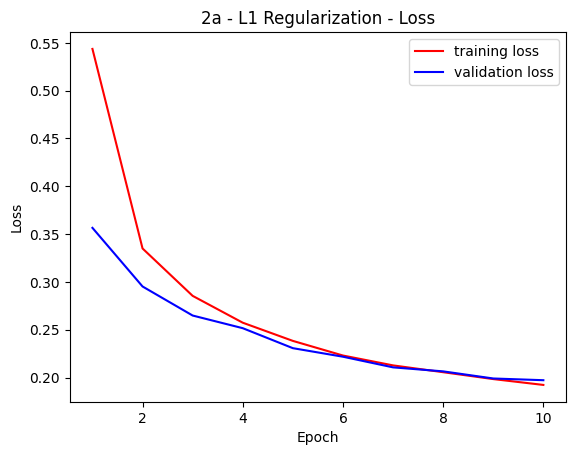

In [34]:
L1_RATE = 0.0001

def build_l1():
    m = Sequential()
    m.add(Input(shape=(28, 28, 1)))
    m.add(Flatten())
    m.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l1(L1_RATE)))
    m.add(Dense(10, activation='softmax', kernel_regularizer=regularizers.l1(L1_RATE)))
    return m

model_l1, history_l1, loss_l1, acc_l1 = run_scenario('2a - L1 Regularization', build_l1)

### 2b. L2 Regularization
Rate L2 didefinisikan sendiri: `L2_RATE = 0.0001`

=== 2b - L2 Regularization ===
Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8915 - loss: 0.4130 - val_acc: 0.9337 - val_loss: 0.2463
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9438 - loss: 0.2197 - val_acc: 0.9487 - val_loss: 0.1942
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9561 - loss: 0.1768 - val_acc: 0.9572 - val_loss: 0.1678
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9640 - loss: 0.1517 - val_acc: 0.9624 - val_loss: 0.1537
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9683 - loss: 0.1359 - val_acc: 0.9663 - val_loss: 0.1390
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9723 - loss: 0.1248 - val_acc: 0.9687 - val_loss: 0.1317
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9756 - loss: 0.1159 - val_acc: 0.9683 - val_loss: 0.1311
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9780 - loss: 0.1092 - val_acc: 0.9717 - val_loss: 0.1253
Epoch 9/10
600/600 ━━━━━━

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_14 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9731 - loss: 0.1212
Akurasi Testing 2b - L2 Regularization: 0.9731000065803528


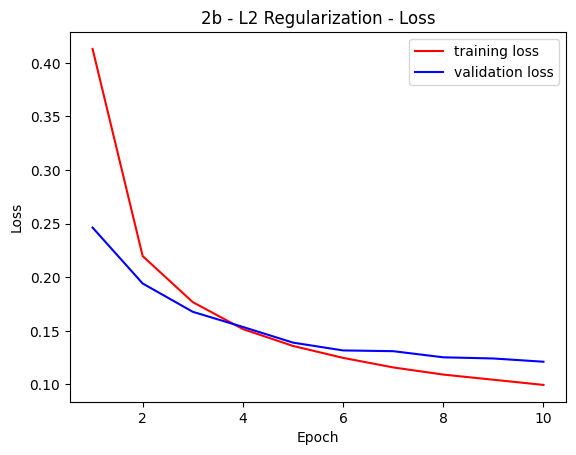

In [35]:
L2_RATE = 0.0001

def build_l2():
    m = Sequential()
    m.add(Input(shape=(28, 28, 1)))
    m.add(Flatten())
    m.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(L2_RATE)))
    m.add(Dense(10, activation='softmax', kernel_regularizer=regularizers.l2(L2_RATE)))
    return m

model_l2, history_l2, loss_l2, acc_l2 = run_scenario('2b - L2 Regularization', build_l2)

### 2c. Dropout
Rate Dropout didefinisikan sendiri: `DROPOUT_RATE = 0.3`

=== 2c - Dropout ===
Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8514 - loss: 0.5101 - val_acc: 0.9351 - val_loss: 0.2289
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9223 - loss: 0.2675 - val_acc: 0.9490 - val_loss: 0.1718
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9360 - loss: 0.2180 - val_acc: 0.9565 - val_loss: 0.1421
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9440 - loss: 0.1891 - val_acc: 0.9626 - val_loss: 0.1265
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9496 - loss: 0.1714 - val_acc: 0.9637 - val_loss: 0.1190
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9545 - loss: 0.1546 - val_acc: 0.9678 - val_loss: 0.1105
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9555 - loss: 0.1472 - val_acc: 0.9695 - val_loss: 0.1042
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9581 - loss: 0.1387 - val_acc: 0.9703 - val_loss: 0.0987
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_15 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9719 - loss: 0.0945
Akurasi Testing 2c - Dropout: 0.9718999862670898


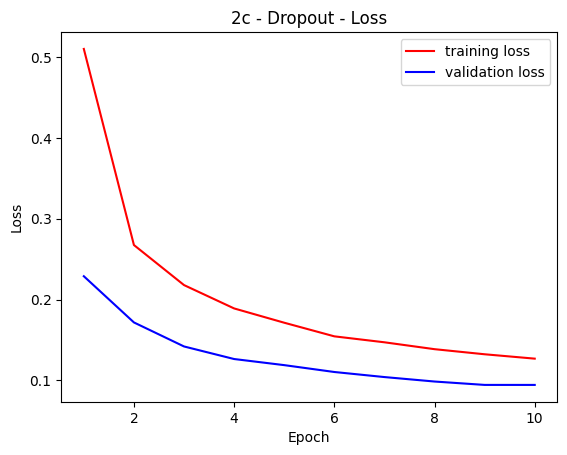

In [36]:
DROPOUT_RATE = 0.3

def build_dropout():
    m = Sequential()
    m.add(Input(shape=(28, 28, 1)))
    m.add(Flatten())
    m.add(Dense(64, activation='relu'))
    m.add(Dropout(DROPOUT_RATE))
    m.add(Dense(10, activation='softmax'))
    return m

model_dropout, history_dropout, loss_dropout, acc_dropout = run_scenario('2c - Dropout', build_dropout)

### 2d. Early Stopping
`EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)`, dengan `epochs` maksimum dinaikkan (mis. 30) agar early stopping punya kesempatan berhenti lebih awal.

=== 2d - Early Stopping ===
Epoch 1/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8930 - loss: 0.3895 - val_acc: 0.9340 - val_loss: 0.2259
Epoch 2/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9461 - loss: 0.1884 - val_acc: 0.9533 - val_loss: 0.1589
Epoch 3/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9595 - loss: 0.1416 - val_acc: 0.9625 - val_loss: 0.1362
Epoch 4/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9668 - loss: 0.1149 - val_acc: 0.9669 - val_loss: 0.1149
Epoch 5/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9719 - loss: 0.0976 - val_acc: 0.9689 - val_loss: 0.1035
Epoch 6/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9756 - loss: 0.0841 - val_acc: 0.9702 - val_loss: 0.1028
Epoch 7/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9780 - loss: 0.0730 - val_acc: 0.9712 - val_loss: 0.0921
Epoch 8/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9809 - loss: 0.0638 - val_acc: 0.9696 - val_loss: 0.0966
Epoch 9/30
600/600 ━━━━━━━━━

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_16 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9765 - loss: 0.0790
Akurasi Testing 2d - Early Stopping: 0.9764999747276306


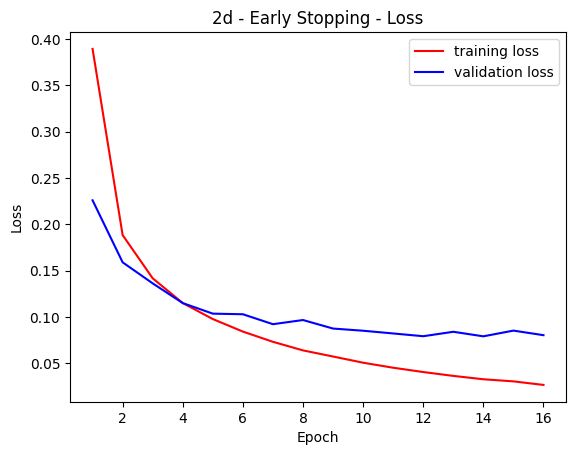

Jumlah epoch aktual sebelum berhenti: 16


In [37]:
def build_es():
    m = Sequential()
    m.add(Input(shape=(28, 28, 1)))
    m.add(Flatten())
    m.add(Dense(64, activation='relu'))
    m.add(Dense(10, activation='softmax'))
    return m

es_callback = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

model_es, history_es, loss_es, acc_es = run_scenario(
    '2d - Early Stopping', build_es, callbacks=[es_callback], epochs=30
)
print('Jumlah epoch aktual sebelum berhenti:', len(history_es.history['loss']))

### 2e. L1 Regularization + Dropout
Menggabungkan `L1_RATE` dan `DROPOUT_RATE` yang sudah didefinisikan di atas.

=== 2e - L1 + Dropout ===
Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - acc: 0.8497 - loss: 0.6582 - val_acc: 0.9289 - val_loss: 0.3800
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - acc: 0.9165 - loss: 0.4203 - val_acc: 0.9447 - val_loss: 0.3212
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9286 - loss: 0.3741 - val_acc: 0.9498 - val_loss: 0.2903
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9340 - loss: 0.3477 - val_acc: 0.9571 - val_loss: 0.2712
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9398 - loss: 0.3261 - val_acc: 0.9609 - val_loss: 0.2511
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9443 - loss: 0.3131 - val_acc: 0.9636 - val_loss: 0.2446
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9463 - loss: 0.3025 - val_acc: 0.9647 - val_loss: 0.2379
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9478 - loss: 0.2981 - val_acc: 0.9666 - val_loss: 0.2342
Epoch 9/10
600/600 ━━━━━━━━━━━

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_17 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,672 (596.38 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 101,782 (397.59 KB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9692 - loss: 0.2234
Akurasi Testing 2e - L1 + Dropout: 0.9692000150680542


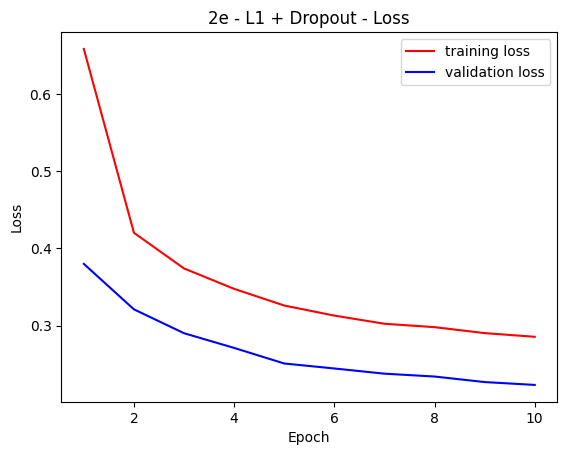

In [38]:
def build_l1_dropout():
    m = Sequential()
    m.add(Input(shape=(28, 28, 1)))
    m.add(Flatten())
    m.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l1(L1_RATE)))
    m.add(Dropout(DROPOUT_RATE))
    m.add(Dense(10, activation='softmax', kernel_regularizer=regularizers.l1(L1_RATE)))
    return m

model_l1d, history_l1d, loss_l1d, acc_l1d = run_scenario('2e - L1 + Dropout', build_l1_dropout)

## 3. Ringkasan Perbandingan Semua Skenario

In [40]:
import pandas as pd

summary = pd.DataFrame({
    'Skenario': ['Base', 'L1', 'L2', 'Dropout', 'Early Stopping', 'L1 + Dropout'],
    'Test Accuracy': [None, acc_l1, acc_l2, acc_dropout, acc_es, acc_l1d],
    'Test Loss': [None, loss_l1, loss_l2, loss_dropout, loss_es, loss_l1d],
})

# Isi baris Base dari hasil evaluasi model1 pada bagian 1
base_loss, base_acc = model1.evaluate(X_test, y_test, verbose=0)
summary.loc[summary['Skenario'] == 'Base', 'Test Accuracy'] = base_acc
summary.loc[summary['Skenario'] == 'Base', 'Test Loss'] = base_loss

summary

,Skenario,Test Accuracy,Test Loss
0,Base,0.9745,0.083599
1,L1,0.9724,0.197172
2,L2,0.9731,0.121208
3,Dropout,0.9719,0.094514
4,Early Stopping,0.9765,0.078969
5,L1 + Dropout,0.9692,0.223361
